In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -q dagshub mlflow==2.22.0 xgboost kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import dagshub

dagshub.init(repo_owner='aleko-mamukashvili', repo_name='Store-Sales-Forecasting', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=347d0370-1e13-47a8-9027-a7b55212abea&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a0f73ebbf2a44848c88cc198ad0e36b294694cdb3d58ec319356060ebe54149a




Accessing as aleko-mamukashvili

Initialized MLflow to track repo "aleko-mamukashvili/Store-Sales-Forecasting"

Repository aleko-mamukashvili/Store-Sales-Forecasting initialized!

In [4]:
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline


class LagFeatureBuilder(BaseEstimator, TransformerMixin):
    def __init__(self, lag_weeks=(51, 52, 53)):
        self.lag_weeks = lag_weeks

    def fit(self, X, y):
        hist = X[['Store', 'Dept', 'Date']].copy()
        hist['Weekly_Sales'] = np.asarray(y)
        self.history_ = hist.drop_duplicates(subset=['Store', 'Dept', 'Date'])
        return self

    def transform(self, X):
        X = X.copy()
        for w in self.lag_weeks:
            shifted = self.history_.copy()
            shifted['Date'] = shifted['Date'] + pd.Timedelta(weeks=w)
            shifted = shifted.rename(columns={'Weekly_Sales': f'Sales_Lag_{w}w'})
            X = X.merge(shifted[['Store', 'Dept', 'Date', f'Sales_Lag_{w}w']],
                        on=['Store', 'Dept', 'Date'], how='left')
        return X


class SeasonalHistFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept', 'Date']].copy()
        tmp['WeekOfYear'] = tmp['Date'].dt.isocalendar().week.astype(int)
        tmp['Weekly_Sales'] = np.asarray(y)
        self.week_means_ = (tmp.groupby(['Store', 'Dept', 'WeekOfYear'])['Weekly_Sales']
                             .mean().reset_index().rename(columns={'Weekly_Sales': 'Hist_Sales'}))
        self.global_mean_ = tmp['Weekly_Sales'].mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X = X.merge(self.week_means_, on=['Store', 'Dept', 'WeekOfYear'], how='left')
        X['Hist_Sales'] = X['Hist_Sales'].fillna(self.global_mean_)
        return X


class GroupStatsFeatureBuilder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        tmp = X[['Store', 'Dept']].copy()
        tmp['Weekly_Sales'] = np.asarray(y)
        self.group_stats_ = (
            tmp.groupby(['Store', 'Dept'])['Weekly_Sales']
               .agg(Group_Mean='mean', Group_Median='median', Group_Std='std')
               .reset_index()
        )
        return self

    def transform(self, X):
        return X.merge(self.group_stats_, on=['Store', 'Dept'], how='left')


class TemporalFeatureBuilder(BaseEstimator, TransformerMixin):
    TYPE_MAP = {'A': 3, 'B': 2, 'C': 1}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['Year'] = X['Date'].dt.year
        X['Month'] = X['Date'].dt.month
        if 'WeekOfYear' not in X.columns:
            X['WeekOfYear'] = X['Date'].dt.isocalendar().week.astype(int)
        X['IsHoliday'] = X['IsHoliday'].astype(int)
        X['Store_Type'] = X['Type'].map(self.TYPE_MAP)
        X = X.drop(columns=['Date', 'Type'], errors='ignore')
        for col in ['Store', 'Dept', 'Store_Type']:
            X[col] = X[col].astype('category')
        return X


class MissingValueHandler(BaseEstimator, TransformerMixin):
    MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for c in self.MARKDOWN_COLS:
            if c in X.columns:
                X[c] = X[c].fillna(0)
        for c in ['CPI', 'Unemployment']:
            if c in X.columns:
                X[c] = X.groupby('Store')[c].transform(lambda s: s.ffill().bfill())
        return X


class DropWeakFeatures(BaseEstimator, TransformerMixin):
    WEAK_COLS = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.WEAK_COLS if c in X.columns])


class XGBFinalEstimator(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=300, learning_rate=0.05, max_depth=8,
                 subsample=0.85, colsample_bytree=0.85, random_state=42,
                 objective='reg:absoluteerror'):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.objective = objective

    def fit(self, X, y, sample_weight=None):
        self.feature_cols_ = list(X.columns)
        self.model_ = xgb.XGBRegressor(
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, subsample=self.subsample,
            colsample_bytree=self.colsample_bytree, random_state=self.random_state,
            objective=self.objective, enable_categorical=True, tree_method='hist',
        )
        self.model_.fit(X[self.feature_cols_], y, sample_weight=sample_weight)
        return self

    def predict(self, X):
        return self.model_.predict(X[self.feature_cols_])

print('✅ კლასები განსაზღვრულია')

✅ კლასები განსაზღვრულია


In [5]:
MODEL_URI = "models:/Walmart_XGBoost_SalesForecast/latest"

best_pipeline = mlflow.sklearn.load_model(MODEL_URI)
print("მოდელი ჩაიტვირთა:", MODEL_URI)
print(best_pipeline)

მოდელი ჩაიტვირთა: models:/Walmart_XGBoost_SalesForecast/latest
Pipeline(steps=[('impute', MissingValueHandler()),
                ('lags', LagFeatureBuilder()),
                ('seasonal_hist', SeasonalHistFeatureBuilder()),
                ('group_stats', GroupStatsFeatureBuilder()),
                ('temporal', TemporalFeatureBuilder()),
                ('model', XGBFinalEstimator(n_estimators=500))])


In [9]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d data/
!unzip -o data/test.csv.zip -d data/
!unzip -o data/features.csv.zip -d data/

walmart-recruiting-store-sales-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: data/features.csv.zip   
  inflating: data/sampleSubmission.csv.zip  
  inflating: data/stores.csv         
  inflating: data/test.csv.zip       
  inflating: data/train.csv.zip      
Archive:  data/test.csv.zip
  inflating: data/test.csv           
Archive:  data/features.csv.zip
  inflating: data/features.csv       


In [10]:
DATA_PATH = "data"

test_raw = pd.read_csv(f"{DATA_PATH}/test.csv")
features_raw = pd.read_csv(f"{DATA_PATH}/features.csv")
stores_raw = pd.read_csv(f"{DATA_PATH}/stores.csv")

test_df = test_raw.merge(features_raw, on=['Store', 'Date'], how='left', suffixes=('', '_feat'))
test_df = test_df.merge(stores_raw, on='Store', how='left')

if 'IsHoliday_feat' in test_df.columns:
    test_df = test_df.drop(columns=['IsHoliday_feat'])

test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df = test_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print("Test shape:", test_df.shape)
print("Date range:", test_df['Date'].min().date(), "->", test_df['Date'].max().date())
test_df.head()

Test shape: (115064, 15)
Date range: 2012-11-02 -> 2013-07-26


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [11]:
lag_step = best_pipeline.named_steps['lags']
known_pairs = set(map(tuple, lag_step.history_[['Store', 'Dept']].drop_duplicates().values))
test_pairs = set(map(tuple, test_df[['Store', 'Dept']].drop_duplicates().values))

unseen_pairs = test_pairs - known_pairs
print(f"Test-ში სულ {len(test_pairs)} უნიკალური (Store, Dept) წყვილი.")
print(f"მათგან {len(unseen_pairs)} არასდროს გვინახავს train-ში.")
if unseen_pairs:
    print("მაგალითები:", list(unseen_pairs)[:5])

Test-ში სულ 3169 უნიკალური (Store, Dept) წყვილი.
მათგან 11 არასდროს გვინახავს train-ში.
მაგალითები: [(np.int64(18), np.int64(43)), (np.int64(24), np.int64(43)), (np.int64(36), np.int64(30)), (np.int64(37), np.int64(29)), (np.int64(25), np.int64(99))]


In [12]:
predictions = best_pipeline.predict(test_df)
pred_series = pd.Series(predictions)

print("Predictions shape:", predictions.shape)
print(pred_series.describe())
print("უარყოფითი predictions:", (pred_series < 0).sum())

Predictions shape: (115064,)
count    115064.000000
mean      16492.271484
std       22950.548828
min        -293.050659
25%        2311.315613
50%        8050.122070
75%       20739.225586
max      281650.218750
dtype: float64
უარყოფითი predictions: 589


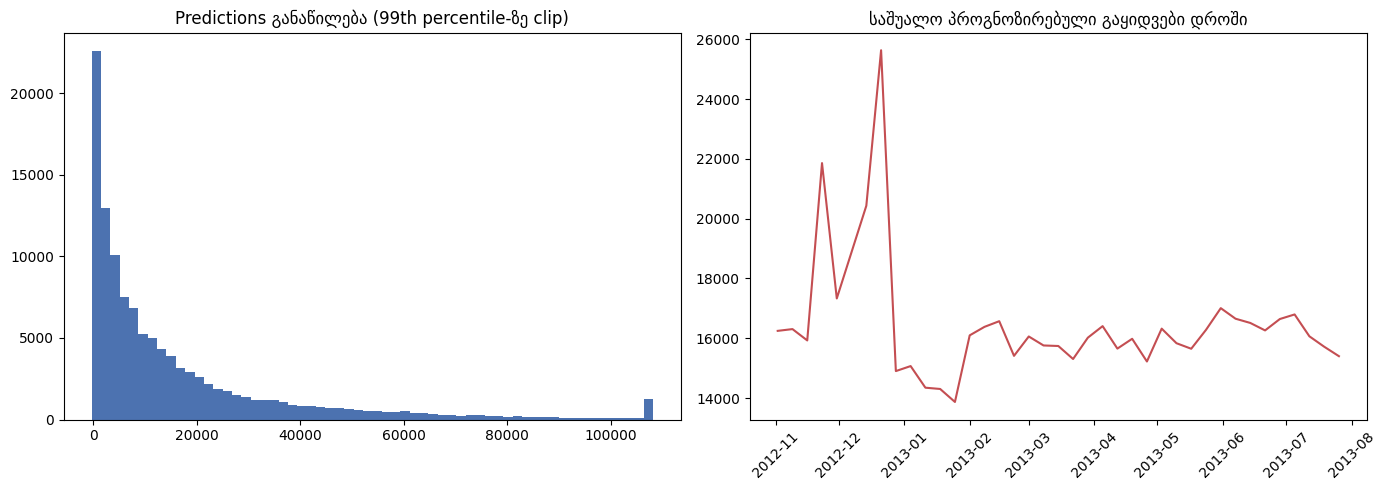

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_series.clip(upper=pred_series.quantile(0.99)), bins=60, color='#4C72B0')
axes[0].set_title('Predictions განაწილება (99th percentile-ზე clip)')

pred_by_week = pd.DataFrame({'Date': test_df['Date'], 'Pred': predictions}).groupby('Date')['Pred'].mean()
axes[1].plot(pred_by_week.index, pred_by_week.values, color='#C44E52')
axes[1].set_title('საშუალო პროგნოზირებული გაყიდვები დროში')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
submission = pd.DataFrame({
    'Id': test_df['Store'].astype(str) + '_' + test_df['Dept'].astype(str) + '_' + test_df['Date'].dt.strftime('%Y-%m-%d'),
    'Weekly_Sales': predictions
})

negative_count = (submission['Weekly_Sales'] < 0).sum()
submission['Weekly_Sales'] = submission['Weekly_Sales'].clip(lower=0)
print(f"{negative_count} უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.")

submission.to_csv('submission.csv', index=False)
print(submission.shape)
submission.head()

589 უარყოფითი პროგნოზი 0-ზე შევკვეცეთ.
(115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,35555.906250
1,1_1_2012-11-09,20217.472656
2,1_1_2012-11-16,20335.425781
3,1_1_2012-11-23,19991.982422
4,1_1_2012-11-30,23830.269531


In [15]:
!kaggle competitions submit \
  -c walmart-recruiting-store-sales-forecasting \
  -f submission.csv \
  -m "XGBoost refactored Pipeline (lags + seasonal_hist + group_stats)"

100% 2.88M/2.88M [00:00<00:00, 5.83MB/s]
Successfully submitted to Walmart Recruiting - Store Sales Forecasting

In [16]:
!kaggle competitions submissions -c walmart-recruiting-store-sales-forecasting

fileName            date                        description                                                       status                     publicScore  privateScore  
------------------  --------------------------  ----------------------------------------------------------------  -------------------------  -----------  ------------  
submission.csv      2026-07-11 16:16:30.913000  XGBoost refactored Pipeline (lags + seasonal_hist + group_stats)  SubmissionStatus.COMPLETE  3247.97676   3377.41106    
submission (1).csv  2026-07-11 09:41:26.343000                                                                    SubmissionStatus.COMPLETE  19846.43567  20160.95791   
